On commence par importer toutes les librairies qui nous seront nécessaires.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    brier_score_loss
)
import xgboost as xgb
import shap

On met en place nos données et notre Encoder (ce qui permet de transformer les labels en valeurs numériques)
On enlève en même temps la variable cible dans notre set de 'predicteurs'.
On applique l'encoder à la variable ("y") cible.

In [2]:
df = pd.read_csv("bank-full.csv", sep=';')

le = LabelEncoder()
y = le.fit_transform(df["y"])
X = df.drop(columns=["y"])

On a besoin de mettre en place 3 jeux de données : 
- L'un pour l'entraînement de notre modèle (X_train)
- Un 2nd pour la validation de notre modèle, ce qui va nous permettre de calibrer (X_val)
- Un dernier pour le test de notre modèle (X_test)

On veut une répartition 70/15/15.
On fait attention à ce que la proportion de 'yes' soit la même parmi les 3 jeux de données, et qu'on coupe de manière aléatoire.
Pour cela on utilise StratifiedShuffleSplit

In [3]:
# Split stratifié : 70% train / 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
for train_idx, temp_idx in sss1.split(X, y):
    X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
    y_train, y_temp = y[train_idx], y[temp_idx]

# Split stratifié : 50% val / 50% test sur le temp (=> 15/15 global)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
for val_idx, test_idx in sss2.split(X_temp, y_temp):
    X_val,  X_test  = X_temp.iloc[val_idx],  X_temp.iloc[test_idx]
    y_val,  y_test  = y_temp[val_idx],        y_temp[test_idx]

print(f"Train : {len(X_train):>6}  ({y_train.mean():.1%} positifs)")
print(f"Val   : {len(X_val):>6}  ({y_val.mean():.1%} positifs)")
print(f"Test  : {len(X_test):>6}  ({y_test.mean():.1%} positifs)")

Train :  31647  (11.7% positifs)
Val   :   6782  (11.7% positifs)
Test  :   6782  (11.7% positifs)


Ici on sépare en fonction du type de variable pour pouvoir utiliser le bon Encoder (par exemple simplement une normalisation pour les variables numériques).

On va pouvoir ensute créer 3 encoders, qu'on va le fit à l'aide du X_train : 
A VERIFIER : est-ce qu'il faut le faire sur les 3 ou uniquement sur le X_train ? Eventuelle fuite d'information ?

In [15]:
categorical_nominal = ["job", "marital", "education", "contact", "month", "poutcome"]
categorical_binary  = ["default", "housing", "loan"]
numerical_features  = ["age", "balance", "day", "campaign", "pdays", "previous"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num",     StandardScaler(),                                    numerical_features),
        ("cat_nom", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_nominal),
        ("cat_bin", OneHotEncoder(drop="if_binary"),                     categorical_binary)
    ]
)

preprocessor.fit(X_train)

print(f"Features : {len(preprocessor.get_feature_names_out())}")

Features : 41


On applique notre encoder aux 3 set de variables prédictives.

In [5]:
# Transform
X_train_final = preprocessor.transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)

On s'appuie sur la fonction d'évaluation proposée par Khadija, qui permet de calculer directement toutes les métrics qui nous intéressent).
Vérifier si on garde ce threshold.

In [6]:
def evaluate_probas(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "roc_auc":   roc_auc_score(y_true, y_proba),
        "pr_auc":    average_precision_score(y_true, y_proba),
        "brier":     brier_score_loss(y_true, y_proba),
        "f1":        f1_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "threshold": threshold,
    }

On met en place notre modèle de régression logistique, qu'on entraîne uniquement à l'aide de X_train_final et y_train

On veut ensuite faire apparaître les probas prédites pour les 3 jeux de données pour voir à l'aide de notre fonction d'évaluation s'il n'y a pas d'overfit.

In [7]:
logreg = LogisticRegression(
    max_iter=500,              # nombre max d’itérations pour converger
    class_weight="balanced",   # gère le déséquilibre
    solver="lbfgs"             # algorithme d’optimisation standard
)

logreg.fit(X_train_final, y_train)

proba_train = logreg.predict_proba(X_train_final)[:, 1]
proba_val   = logreg.predict_proba(X_val_final)[:, 1]
proba_test  = logreg.predict_proba(X_test_final)[:, 1]

results = pd.DataFrame([
    {"split": "train", **evaluate_probas(y_train, proba_train, 0.5)},
    {"split": "val",   **evaluate_probas(y_val,   proba_val,   0.5)},
    {"split": "test",  **evaluate_probas(y_test,  proba_test,  0.5)},
])

results

,split,roc_auc,pr_auc,brier,f1,recall,precision,threshold
0,train,0.768313,0.397489,0.184473,0.375426,0.625608,0.268180,0.5
1,val,0.771820,0.416180,0.183913,0.375000,0.627204,0.267454,0.5
2,test,0.768115,0.414500,0.182322,0.373253,0.622951,0.266451,0.5


Ici, je prend un raccourci en utilisant directement l'hyperparamètre de régularisation C=0.1 déterminé par Khadija afin de proposer une meilleure pénalisation dans notre modèle de régression logistique.

In [8]:
#J'utilise le résultat déjà trouvé avant que C=0.1 soit le meilleur hyperparamètre pour la régularisation de la régression logistique. Je réentraîne donc un modèle avec ce paramètre et j'évalue à nouveau les performances sur l'ensemble de validation.
best_logreg = LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs", C=0.1)
best_logreg.fit(X_train_final, y_train)

proba_val_tuned = best_logreg.predict_proba(X_val_final)[:, 1]
print(evaluate_probas(y_val, proba_val_tuned, threshold=0.5))

{'roc_auc': np.float64(0.7721887940448486), 'pr_auc': np.float64(0.415556113626157), 'brier': np.float64(0.1845520378165693), 'f1': 0.3759342301943199, 'recall': 0.6335012594458438, 'precision': 0.26726886291179597, 'threshold': 0.5}


Ici nous souhaitons calibrer nos proba à l'aide d'une regression isotonic, afin qu'elle fit davantage à la réalité.

In [9]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
import matplotlib.pyplot as plt

calibrated_logreg_iso = CalibratedClassifierCV(best_logreg, method='isotonic', cv='prefit')
calibrated_logreg_iso.fit(X_val_final, y_val)
proba_val_calibrated_iso = calibrated_logreg_iso.predict_proba(X_val_final)[:, 1]

# Je n'affiche pas les courbes etc, ici c'est surtout intermédiaire

c:\Users\Maxime\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Nous créons un array qui donné les probas prédites à l'aide du set de variables prédictives du set final (X_test_final), après calibration.
On calcule ensuite l'enthropie pour chacune des valeurs.

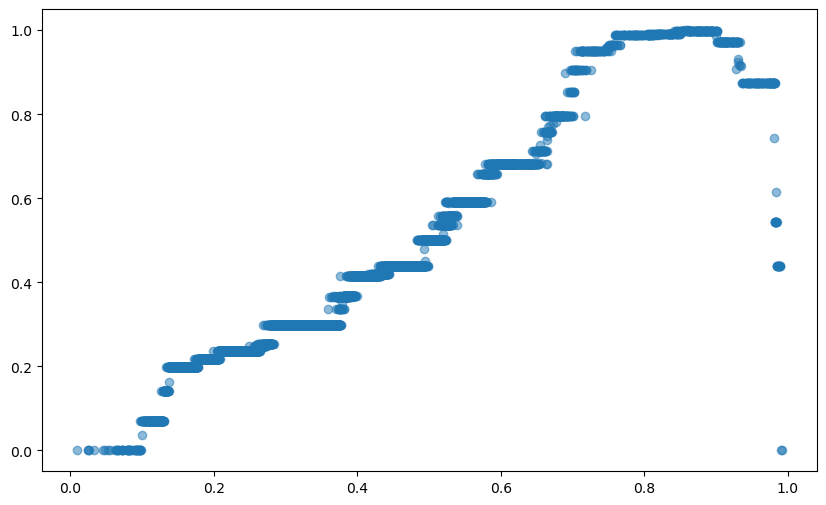

In [10]:
p = calibrated_logreg_iso.predict_proba(X_test_final)[:, 1]
p = np.clip(p, 1e-10, 1 - 1e-10)  # évite log2(0)
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
plt.figure(figsize=(10, 6))
plt.scatter(proba_test, entropy, alpha=0.5)

Dernière étape : on fait attention d'abord qu'on ait pas un array sparsed (d'où le .toarray())

On entraîne un modèle supervisé visant à approximer l’entropie des prédictions du modèle initial. Cette étape permet de transformer une mesure d’incertitude en une cible prédictive.

L’analyse des valeurs de SHAP associées à ce modèle permet ensuite d’identifier les variables qui contribuent le plus aux variations de cette entropie, c’est-à-dire celles qui caractérisent les régions de l’espace d’entrée où le modèle est le plus incertain.

100%|===================| 6755/6782 [00:59<00:00]        

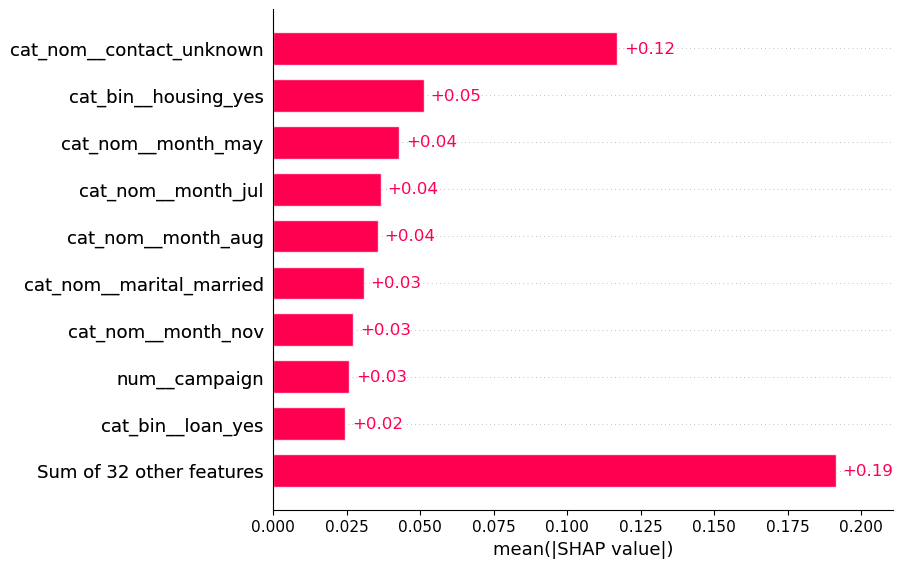

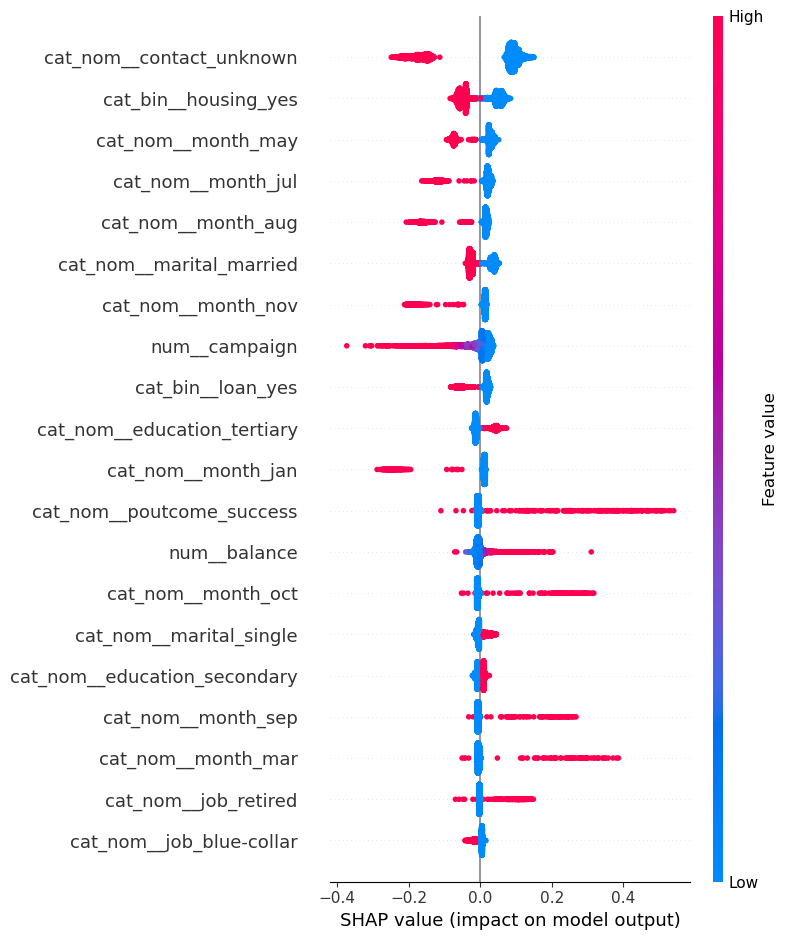

In [14]:
import pandas as pd

X_test_dense = X_test_final.toarray()
feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_dense, columns=feature_names)


xgb_entropy = xgb.XGBRegressor(n_estimators=300, max_depth=4, random_state=42)
xgb_entropy.fit(X_test_df, entropy)

explainer = shap.Explainer(xgb_entropy, X_test_df)
shap_values = explainer(X_test_df)

shap.plots.bar(shap_values)
shap.summary_plot(shap_values, X_test_df)